# Ejercicios ensembling
En este ejercicio vas a realizar prediciones sobre un dataset de ciudadanos indios diabéticos. Se trata de un problema de clasificación en el que intentaremos predecir 1 (diabético) 0 (no diabético).

### 1. Carga las librerias que consideres comunes al notebook

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns


### 2. Lee los datos de [esta direccion](https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv)
Los nombres de columnas son:
```Python
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
```

In [8]:
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv")
df


,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...
762,10,101,76,48,180,32.9,0.171,63,0
763,2,122,70,27,0,36.8,0.340,27,0
764,5,121,72,23,112,26.2,0.245,30,0
765,1,126,60,0,0,30.1,0.349,47,1


In [10]:
df.columns = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
df

,preg,plas,pres,skin,test,mass,pedi,age,class
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...
762,10,101,76,48,180,32.9,0.171,63,0
763,2,122,70,27,0,36.8,0.340,27,0
764,5,121,72,23,112,26.2,0.245,30,0
765,1,126,60,0,0,30.1,0.349,47,1


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    767 non-null    int64  
 1   plas    767 non-null    int64  
 2   pres    767 non-null    int64  
 3   skin    767 non-null    int64  
 4   test    767 non-null    int64  
 5   mass    767 non-null    float64
 6   pedi    767 non-null    float64
 7   age     767 non-null    int64  
 8   class   767 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe() # segun la media hay mucha diferencia de escala, entre ellas, ejemplo: 3.83 y segunda columna 120.85, esto tiene pinta que hay que hacer un escalado.

,preg,plas,pres,skin,test,mass,pedi,age,class
count,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000
mean,3.842243,120.859192,69.101695,20.517601,79.903520,31.990482,0.471674,33.219035,0.348110
std,3.370877,31.978468,19.368155,15.954059,115.283105,7.889091,0.331497,11.752296,0.476682
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243500,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,32.000000,32.000000,0.371000,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,127.500000,36.600000,0.625000,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<Axes: >

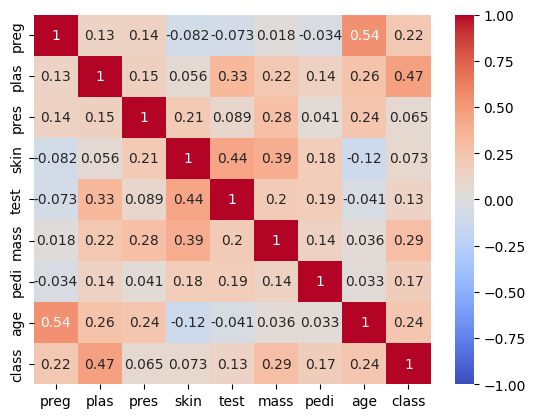

In [21]:
# ver correlaciones.
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", vmin=-1)

### 3. Bagging
Para este apartado tendrás que crear un ensemble utilizando la técnica de bagging ([BaggingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html)), mediante la cual combinarás 100 [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html). Recuerda utilizar también [cross validation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) con 10 kfolds.

**Para este apartado y siguientes, no hace falta que dividas en train/test**, por hacerlo más sencillo. Simplemente divide tus datos en features y target.

Establece una semilla

In [13]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score

In [ ]:
# 1. Definimos la semilla para que los resultados sean reproducibles
semilla = 42
#Separamos en features (X) y target (y)
X = df.drop('class', axis=1)
y = df['class']

# 3. Configuramos el modelo base (Árbol de Decisión)
arbol_base = DecisionTreeClassifier(random_state=semilla)

# 4. Creamos el Ensemble de Bagging
#n_estimator = 100 indica que usare 100 árbores.
model_bagging = BaggingClassifier(estimator = arbol_base, n_estimators= 100, random_state= semilla)

# 5. Configuramos Cross Validation (KFold con 10 divisiones)
k_fold = KFold(n_splits = 10, shuffle= True,random_state= semilla)


In [ ]:
# 6. Evaluamos el modelo
resultado = cross_val_score(model_bagging, X, y, cv=k_fold)
# Mostramos el resultado promedio
print(f"Precisión media: {resultado.mean() * 100:.2f}%")
#Precision mide cuántas predicciones acerta el modelo, en mi caso el  modelo acierta el 75% de las veces los datos.

Precisión media: 75.36%


### 4. Random Forest
En este caso entrena un [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) con 100 árboles y un `max_features` de 3. También con validación cruzada

In [33]:
from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import KFold, cross_val_score

In [35]:
# 1. Definimos la semilla para que los resultados sean reproducibles
semilla = 42

# 2. definimos el Random Forest
    # n_estimators=100: Número de árboles
    # max_features=3: Número de variables a considerar en cada división
modelo_ranf = RandomForestClassifier(n_estimators=100, max_features=3, random_state=semilla)

# 3. definimos la validación cruzada (10 k-folds)
kfold = KFold(n_splits=10, shuffle=True, random_state=semilla)

# 4. Evaluamos el modelo
resultado_ranf  = cross_val_score(modelo_ranf, X, y, cv =kfold)


In [ ]:
# 4. Evaluamos el modelo
resultado_ranf  = cross_val_score(modelo_ranf, X, y, cv =kfold)

# 5. Resultado
print(f"Precisión media de Random Forest: {resultado_ranf.mean() * 100:.2f}%")

# Este  modelo acierta aproximadamente 76 de cada 100 casos en datos nuevos (validación cruzada), algo mejor que el modelo anterior.

Precisión media de Random Forest: 76.13%


### 5. AdaBoost
Implementa un [AdaBoostClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) con 30 árboles.

In [38]:
from sklearn.ensemble import AdaBoostClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.model_selection import cross_val_score, KFold

In [ ]:
#1 definimos el kford para la validación cruzada(es el que hace las particiones para la validación cruzada)
kfold=  KFold(n_splits=10, random_state=42, shuffle=True)

#2 Definimos el modelo
model_ada = AdaBoostClassifier(n_estimators=30, random_state=42)

#3 Evaluamos el modelo usando validación cruzada
resultado_ada = cross_val_score(model_ada, X, y, cv=kfold)

#4 Mostramos el resultado promedio
print("Precisión media de AdaBoost: %.2f%%" % (results_ada.mean()*100))


In [ ]:
# 5.1 Definimos el modelo
# Usaremos 30 árboles de decisión (n_estimators)
model_ada = AdaBoostClassifier(n_estimators=30, random_state=7)

# 5.2 Evaluamos el modelo usando validación cruzada
resultado_ada = cross_val_score(model_ada, X, y, cv=kfold)

# 5.3 Mostramos el resultado promedio
precision = round(resultado_ada.mean() * 100, 2)
print("Precisión media de AdaBoost:", precision, "%")

Precisión media de AdaBoost: 76.14 %


### 6. GradientBoosting
Implementa un [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) con 100 estimadores

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
#1 definimos el kford para la validación cruzada(es el que hace las particiones para la validación cruzada)
kfold=  KFold(n_splits=10, random_state=42, shuffle=True)

# 2. Definimos el modelo con 100 estimadores como pide el enunciado
# Mantenemos random_state=42 
model_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

# 2. Evaluamos el modelo usando validación cruzada (KFold)

resultado_gb = cross_val_score(model_gb, X, y, cv=kfold)

# 3. Mostramos el resultado
print(f"Precisión media de Gradient Boosting: {resultado_gb.mean()*100:.2f}%")

#la precision media ha bajado respecto al anterior modelo.

Precisión media de Gradient Boosting: 74.96%


### 7. XGBoost
Para este apartado utiliza un [XGBoostClassifier](https://docs.getml.com/latest/api/getml.predictors.XGBoostClassifier.html) con 100 estimadores. XGBoost no forma parte de la suite de modelos de sklearn, por lo que tendrás que instalarlo con pip install

In [ ]:
from xgboost import XGBClassifier
# from sklearn.model_selection import cross_val_score, KFold

In [ ]:
#1 definimos el kford para la validación cruzada(es el que hace las particiones para la validación cruzada)
kfold = KFold(n_splits=10, random_state=42, shuffle=True)

# 2. Definir el modelo XGBoost
# n_estimators=100 es lo que pide tu ejercicio
model_xgb = XGBClassifier(n_estimators=100, random_state=42) # 100 estimadores, con 700 y pico registros es excesivo

# 3. Evaluar el modelo con validación cruzada
resultado_xgb = cross_val_score(model_xgb, X, y, cv=kfold)

# 4. Mostrar la precisión (usando f-string que es más moderno)
print(f"Precisión media de XGBoost: {resultado_xgb.mean()*100:.2f}%")

#la precision media ha bajado un 1% respecto al anterior modelo.

Precisión media de XGBoost: 73.65%


### 8. Primeros resultados
Crea un dataframe con los resultados y sus algoritmos, ordenándolos de mayor a menor

In [50]:
#1. Creamos un diccionario con los nombres de los modelos y sus resultados.
 
Modelos = {
     'Nombre_ml': ['Bagging', 'Random_Forest', 'Ada_boost', 'Gradient_boost', 'XGBoost'],
     'Precisión':[
         resultado.mean(),
         resultado_ranf.mean(),
         resultado_ada.mean(),
         resultado_gb.mean(),
         resultado_xgb.mean()
         ]
 }
 
#2. Creamos uin DataFrame
df_modelos =pd.DataFrame(Modelos)

# 3. Ordenamos de mayor a menor por la columna Precisión
df_modelos = df_modelos.sort_values(by='Precisión', ascending=False)
df_modelos

 

,Nombre_ml,Precisión
2,Ada_boost,0.761364
1,Random_Forest,0.761347
0,Bagging,0.753640
3,Gradient_boost,0.749624
4,XGBoost,0.736517


### 9. Hiperparametrización
Vuelve a entrenar los modelos de nuevo, pero esta vez dividiendo el conjunto de datos en train/test y utilizando un gridsearch para encontrar los mejores hiperparámetros.

### 10. Conclusiones finales